In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
ours = pd.read_csv("pathfinding_ours_benchmark.csv")
networkx = pd.read_csv("pathfinding_networkx_benchmark.csv")
networkit = pd.read_csv("pathfinding_networkit_benchmark.csv")

# Our method has two timings. Present them as two series:
#   - "ours: subgraph"   -> edge-induced subgraph extraction (primary output)
#   - "ours: enumerate"  -> subgraph extraction + full path enumeration (t_total)
# The baselines compute the enumeration object, so compare them to "ours: enumerate".
ours_subgraph = ours.copy()
ours_subgraph["method"] = "ours: subgraph"
ours_subgraph["plot_time"] = ours_subgraph["t_subgraph"]
 
ours_enum = ours.copy()
ours_enum["method"] = "ours: enumerate"
ours_enum["plot_time"] = ours_enum["t_total"]
 
networkx["method"] = "networkx"
networkx["plot_time"] = networkx["t_total"]
 
networkit["method"] = "networkit"
networkit["plot_time"] = networkit["t_total"]
 
out = pd.concat(
    [ours_subgraph, ours_enum, networkx, networkit],
    ignore_index=True,
)
out

,method,source_type,dn_type,path_length,t_subgraph,t_enumerate,t_total,source_count,target_count,n_connections,n_paths,plot_time
0,ours: subgraph,JO-EDP,DNa15,2,0.449416,0.000443,0.449860,12,2,7.0,4,0.449416
1,ours: subgraph,JO-EDP,DNpe043,2,0.158984,0.000000,0.158984,12,2,0.0,0,0.158984
2,ours: subgraph,JO-EDP,DNge071,2,0.489494,0.000706,0.490201,12,16,15.0,12,0.489494
3,ours: subgraph,JO-EDP,DNge055,2,0.138314,0.000000,0.138314,12,2,0.0,0,0.138314
4,ours: subgraph,JO-EDP,DNp46,2,0.271930,0.000195,0.272125,12,2,2.0,1,0.271930
...,...,...,...,...,...,...,...,...,...,...,...,...
345,networkit,ORN_DM3,DNa15,4,NaN,NaN,12.720080,61,2,NaN,192184,12.720080
346,networkit,ORN_DM3,DNpe043,4,NaN,NaN,1857.847954,61,2,NaN,2444119,1857.847954
347,networkit,ORN_DM3,DNge071,4,NaN,NaN,15.857826,61,16,NaN,6663,15.857826
348,networkit,ORN_DM3,DNge055,4,NaN,NaN,18.864852,61,2,NaN,234783,18.864852


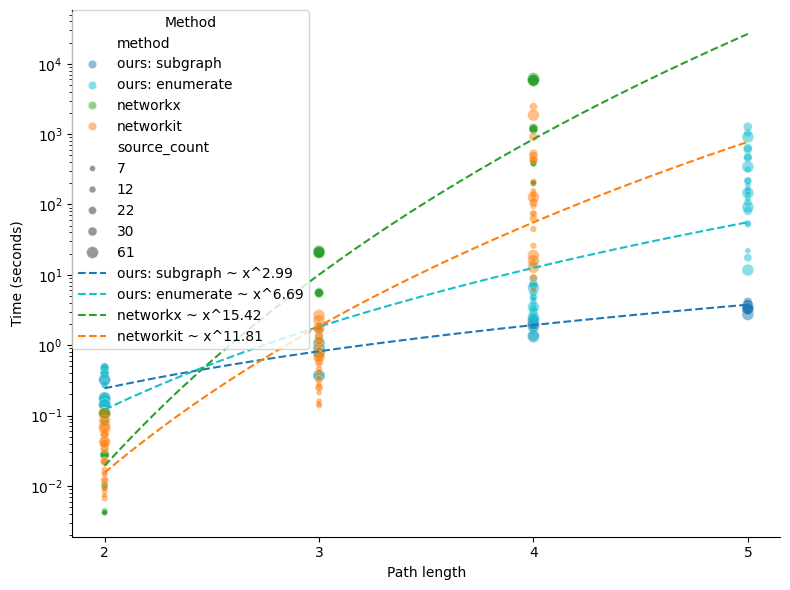

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

color_map = {
    "ours: subgraph": "#1f77b4",   # blue
    "ours: enumerate": "#17becf",  # cyan
    "networkx": "#2ca02c",         # green
    "networkit": "#ff7f0e",        # orange
}
methods = [m for m in color_map if m in out["method"].unique()]

plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    data=out[out["method"].isin(methods)],
    x="path_length",
    y="plot_time",
    size="source_count",
    hue="method",
    hue_order=methods,
    palette=color_map,
    alpha=0.5,
)
ax.set_yscale("log")

# fit lines overlaid on the same axes
for m in methods:
    sub = out[out["method"] == m]
    x = sub["path_length"].to_numpy(float)
    y = sub["plot_time"].to_numpy(float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[mask], y[mask]
    if len(x) < 2:
        continue
    b, logc = np.polyfit(np.log(x), np.log(y), 1)
    c = np.exp(logc)
    # extrapolate baselines (capped at length 4) out to 5 as dashed lines
    x_line = np.linspace(x.min(), 5, 200)
    y_line = c * x_line ** b
    plt.plot(x_line, y_line, "--", color=color_map[m], label=f"{m} ~ x^{b:.2f}")

# --- cosmetics
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yscale("log")
xticks = np.unique(out["path_length"].astype(int))
plt.xticks(ticks=xticks)
plt.xlabel("Path length")
plt.ylabel("Time (seconds)")

# de-duplicate legend (scatter hue + fit lines repeat method names)
handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    seen.setdefault(l, h)
plt.legend(seen.values(), seen.keys(), title="Method",
        #    bbox_to_anchor=(1.02, 1), 
           loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.savefig("pathfinding_benchmark.pdf", bbox_inches="tight")
plt.show()

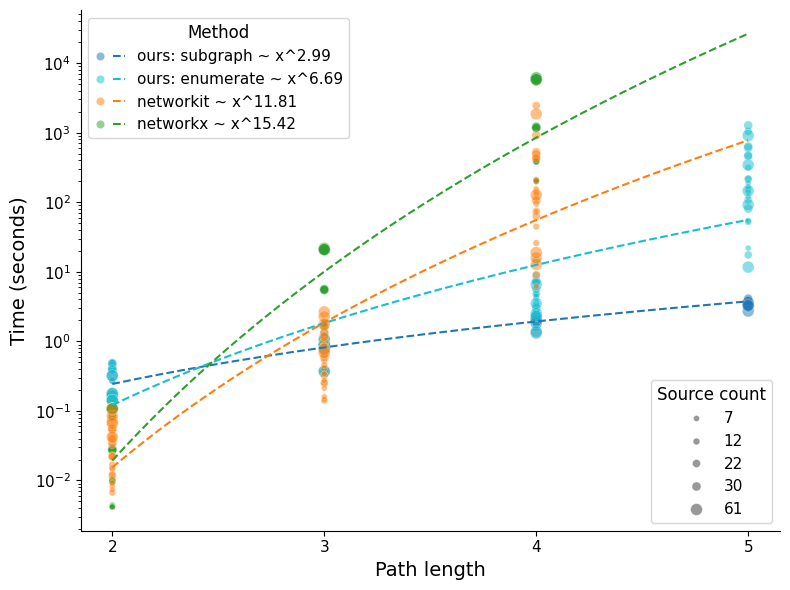

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.legend_handler import HandlerTuple

color_map = {
    "ours: subgraph": "#1f77b4",
    "ours: enumerate": "#17becf",
    "networkit": "#ff7f0e",
    "networkx": "#2ca02c",
}
methods = [m for m in color_map if m in out["method"].unique()]

plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    data=out[out["method"].isin(methods)],
    x="path_length", y="plot_time",
    size="source_count", hue="method",
    hue_order=methods, palette=color_map, alpha=0.5,
)
ax.set_yscale("log")

# fit lines — store handle + exponent per method, but DON'T label them
fit_handles = {}
for m in methods:
    sub = out[out["method"] == m]
    x = sub["path_length"].to_numpy(float)
    y = sub["plot_time"].to_numpy(float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[mask], y[mask]
    if len(x) < 2:
        continue
    b, logc = np.polyfit(np.log(x), np.log(y), 1)
    c = np.exp(logc)
    x_line = np.linspace(x.min(), 5, 200)
    (line,) = plt.plot(x_line, c * x_line ** b, "--", color=color_map[m])
    fit_handles[m] = (line, b)

# cosmetics
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
xticks = np.unique(out["path_length"].astype(int))
plt.xticks(ticks=xticks, fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel("Path length", fontsize=14)
plt.ylabel("Time (seconds)", fontsize=14)

# --- legends ---
handles, labels = ax.get_legend_handles_labels()
hl = dict(zip(labels, handles))

def is_num(s):
    try:
        float(s); return True
    except (ValueError, TypeError):
        return False

# one combined entry per method: scatter dot + dashed fit line in the same slot
method_handles, method_labels = [], []
for m in methods:
    if m in fit_handles and m in hl:
        line, b = fit_handles[m]
        method_handles.append((hl[m], line))
        method_labels.append(f"{m} ~ x^{b:.2f}")

# reuse seaborn's size swatches, just relabel the title
size_handles = [h for h, l in zip(handles, labels) if is_num(l)]
size_labels  = [l for l in labels if is_num(l)]

leg1 = ax.legend(method_handles, method_labels, title="Method",
                 handler_map={tuple: HandlerTuple(ndivide=None)},
                 loc="upper left", borderaxespad=0.5, fontsize=11, title_fontsize=12)
ax.add_artist(leg1)            # keep leg1 when we add the second legend
ax.legend(size_handles, size_labels, title="Source count",
          loc="lower right", borderaxespad=0.5, fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.savefig("pathfinding_benchmark.pdf", bbox_inches="tight")
plt.show()

In [5]:
# Median time per method at each path length, plus the n_paths vs n_connections
# contrast that motivates returning the subgraph rather than enumerating.
summary = (
    out.groupby(["method", "path_length"])
    .agg(
        median_time_s=("plot_time", "median"),
        max_time_s=("plot_time", "max"),
    )
    .round(3)
    .reset_index()
)
print(summary.to_string(index=False))

         method  path_length  median_time_s  max_time_s
      networkit            2          0.023       0.108
      networkit            3          0.587       2.654
      networkit            4        110.862    2450.523
       networkx            2          0.028       0.108
       networkx            3          5.499      21.771
       networkx            4       1189.314    6167.127
ours: enumerate            2          0.173       0.490
ours: enumerate            3          0.945       1.727
ours: enumerate            4          4.420      14.364
ours: enumerate            5        168.832    1271.717
 ours: subgraph            2          0.173       0.489
 ours: subgraph            3          0.936       1.404
 ours: subgraph            4          2.012       2.406
 ours: subgraph            5          3.486       4.120
